# Пространство имен и области видимости

**Пространство имен** - это символическая таблица, которая ставит в соответстиве именам объекты в памяти. 

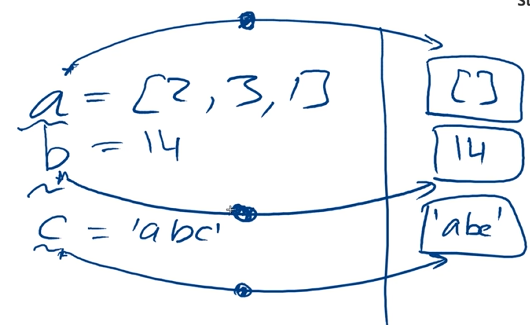

* Пространство имен создается каждый раз при вызове функции. 
* Первое пространство имен, которое создается - это пространство имен, которое создается при запуске интерпретатора - пространство имен встроенных классов и типов и функций стандартной библиотеки builtins.
* main - простарснтво имен на самом высоком уровне программы. 
* Каждый раз когда функция исполняется и снимается со стека разрушается локальное пространство имен этой функции. 

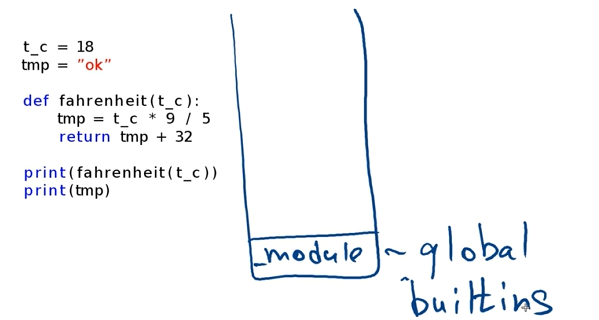

Интерпретатор смотрит на стек сверху вниз. 
Сначала она будет смотрит print в неймспейсе глобал, а потом в билтинс.
затем смотрит фаренгейт в глобалс, затем ищет t_c в глобалс. 

когда мы вызываем фаренгейт, то создается локальный неймспейс этой функции. В нем сначала будет хранится только один аргумент, который мы объявили - это t_c. Ему присваивается 18. В локальном неймспейсе он смотрит значения, на которые ссылается t_c - это 18. 
В локальном неймспейсе создается tmp и ему присваивается результат вычисления. 

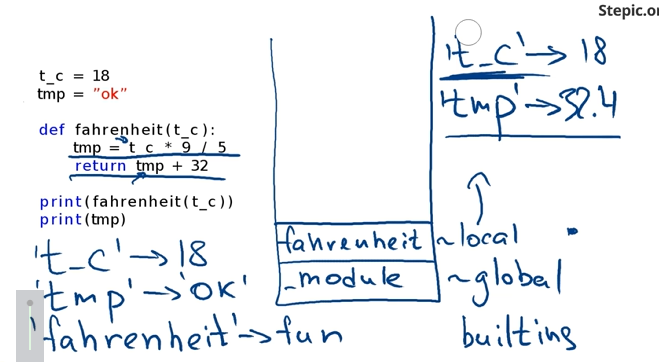

Далее функция принт создаст локальный неймспейс. после ее выполнения и ее локальный неймспейс удалится. 

Это возволяет использовать одни и теже имена в разных частях программы. 

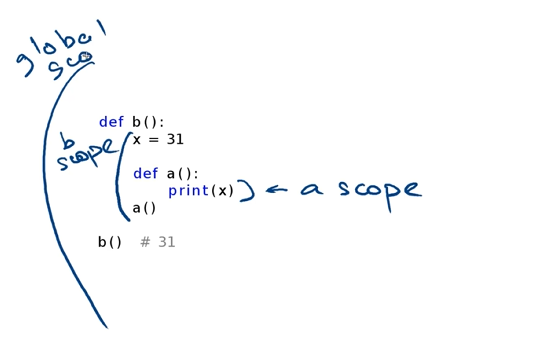

* глобальный неймспейс - глобальная область видимости ()
* локальный неймспейс - локальная область видимости

При поиске переменной верно правило LEGB: 
* L - LOCAL SCOPE
* E - ENCLOSING SCOPE
* G - GLOBAL SCOPE
* B - BUILTINS SCOPE

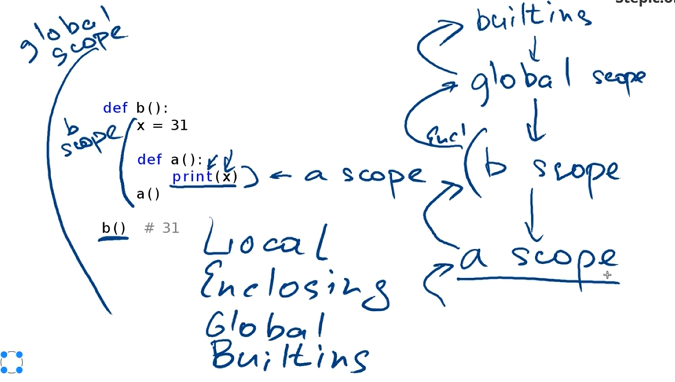

При циклах и условных оператах не создается пространства имен. Они в том текущем пространстве, в котором вызывались. 

In [401]:
def f():
    ok_status = True
    vowels = ['a', 'u', 'i', 'e', 'o']

    def check(word):
        nonlocal ok_status
        for vowel in vowels:
            if vowel in word:
                return True
        ok_status = False
        return False

    print(check('avde'))
    print(ok_status)
    print(check('www'))
    print(ok_status)
f()

True
True
False
False


**Эмуляция работы пространства имен**

Вашей программе на вход подаются следующие запросы:

* ``create <namespace> <parent>`` –  создать новое пространство имен с именем ``<namespace>`` внутри пространства ``<parent>``
* ``add <namespace> <var>`` – добавить в пространство ``<namespace>`` переменную ``<var>``
* ``get <namespace> <var>`` – получить имя пространства, из которого будет взята переменная ``<var>`` при запросе из пространства ``<namespace>``, или None, если такого пространства не существует

In [404]:
S='create <namespace> <parent>'
S.rfind('create')

0

In [467]:
n = int(input())
scopes = {'global': {'parent': None, 'variables': set()}}
qs=[input() for i in range(n)]

def q_reader(q):
    q0,q1,q2=q.split(' ')
    global scopes
    
    def create(q1, q2):
        scopes[q1]={'parent': q2, 'variables': set()}
    def add(q1,q2):
        scopes[q1]['variables'].add(q2)
    def get(q1,q2):
        if q2 in scopes[q1]['variables']:
            return q1
        else:
            q1=scopes[q1]['parent']
            if q1 is None:
                return None
            return get(q1, q2)
            
    if q0=='create':
        create(q1, q2)
    elif q0=='add':
        add(q1,q2)
    elif q0=='get':
        print(get(q1,q2))
            

for i in qs:
    q_reader(i)

global
None
bar
foo


In [430]:
info = dict({'global':[None]})

def create(namespace, parent):
    info.update({namespace:[parent]})

def add(namespace, var):
    info[namespace].append(var)

def get(namespace, var):
    while namespace != None and var not in info[namespace][1:]:
        namespace = info[namespace][0]
    print(namespace)

operations = {'create': create, 'add': add, 'get': get}
for i in range(int(input())):
    inp = input().split()
    operations[inp[0]](inp[1], inp[2])

['add global a', 'create foo global', 'add foo b', 'get foo a']

* ``vars(f)``, ``f.__dict__`` - пространство имен переменной

In [93]:
import math
vars(math).items()

dict_items([('__name__', 'math'), ('__doc__', 'This module provides access to the mathematical functions\ndefined by the C standard.'), ('__package__', ''), ('__loader__', <class '_frozen_importlib.BuiltinImporter'>), ('__spec__', ModuleSpec(name='math', loader=<class '_frozen_importlib.BuiltinImporter'>, origin='built-in')), ('acos', <built-in function acos>), ('acosh', <built-in function acosh>), ('asin', <built-in function asin>), ('asinh', <built-in function asinh>), ('atan', <built-in function atan>), ('atan2', <built-in function atan2>), ('atanh', <built-in function atanh>), ('cbrt', <built-in function cbrt>), ('ceil', <built-in function ceil>), ('copysign', <built-in function copysign>), ('cos', <built-in function cos>), ('cosh', <built-in function cosh>), ('degrees', <built-in function degrees>), ('dist', <built-in function dist>), ('erf', <built-in function erf>), ('erfc', <built-in function erfc>), ('exp', <built-in function exp>), ('exp2', <built-in function exp2>), ('expm1'

* ``dir(f)`` - имена

In [97]:
dir(math)

['__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'acos',
 'acosh',
 'asin',
 'asinh',
 'atan',
 'atan2',
 'atanh',
 'cbrt',
 'ceil',
 'comb',
 'copysign',
 'cos',
 'cosh',
 'degrees',
 'dist',
 'e',
 'erf',
 'erfc',
 'exp',
 'exp2',
 'expm1',
 'fabs',
 'factorial',
 'floor',
 'fmod',
 'frexp',
 'fsum',
 'gamma',
 'gcd',
 'hypot',
 'inf',
 'isclose',
 'isfinite',
 'isinf',
 'isnan',
 'isqrt',
 'lcm',
 'ldexp',
 'lgamma',
 'log',
 'log10',
 'log1p',
 'log2',
 'modf',
 'nan',
 'nextafter',
 'perm',
 'pi',
 'pow',
 'prod',
 'radians',
 'remainder',
 'sin',
 'sinh',
 'sqrt',
 'tan',
 'tanh',
 'tau',
 'trunc',
 'ulp']

* ``__doc__`` - докстринг модуля
* ``__name__`` - имя модуля

## Имена интерактивной сессии

In [96]:
%whos

Variable      Type       Data/Info
----------------------------------
ElementTree   module     <module 'xml.etree.Elemen<...>\\etree\\ElementTree.py'>
b             int        0
color         str        green
color_book    dict       n=3
deepness      int        3825112
deepnesss     int        0
g             int        0
i             int        3
match         Match      <re.Match object; span=(0, 6), match='Привет'>
math          module     <module 'math' (built-in)>
node          Element    <Element 'cube' at 0x000001DC0C5D9D50>
r             int        0
re            module     <module 're' from 'C:\\Us<...>3\\Lib\\re\\__init__.py'>
regex         str        П.+?т
t             list       n=0
text          str        Привет, как тебя зовут?
tree          Element    <Element 'cube' at 0x000001DC0C5D9CB0>


In [98]:
print(__name__)

__main__


## Глобальное пространство имен

In [101]:
dir()[0:10] # первые 10 имен в __main__

['ElementTree', 'In', 'Out', '_', '_1', '_10', '_100', '_18', '_19', '_20']

In [102]:
dir(__builtins__)[0:10] # первые 10 имен в __builtins__

['ArithmeticError',
 'AssertionError',
 'AttributeError',
 'BaseException',
 'BaseExceptionGroup',
 'BlockingIOError',
 'BrokenPipeError',
 'BufferError',
 'BytesWarning',
 'ChildProcessError']

## Использование Python-tutor для визуализации пространст имен

In [112]:
!pip install tutormagic
!jupyter nbextension install --overwrite --py tutormagic
!jupyter nbextension enable --py tutormagic

Traceback (most recent call last):
  File "C:\Users\79618\anaconda3\Scripts\jupyter-nbextension-script.py", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "C:\Users\79618\anaconda3\Lib\site-packages\jupyter_core\application.py", line 277, in launch_instance
    return super().launch_instance(argv=argv, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\79618\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\79618\anaconda3\Lib\site-packages\notebook\nbextensions.py", line 972, in start
    super().start()
  File "C:\Users\79618\anaconda3\Lib\site-packages\jupyter_core\application.py", line 266, in start
    self.subapp.start()
  File "C:\Users\79618\anaconda3\Lib\site-packages\notebook\nbextensions.py", line 702, in start
    self.install_extensions()
  File "C:\Users\79618\anaconda3\Lib\site-packages\notebook\nbextensions.py", line 675, in install_extensions


In [117]:
%load_ext tutormagic
%%tutor --lang python3
def g(x):
    a=1
    x=x+a
    return x
a=0
y=g(10)
print(a,y)

In [115]:
def g(x):
    a=1
    x=x+a
    return x
a=0
y=g(10)
print(a,y)

0 11


In [116]:
%%tutor --lang python3
def f(x):
    x = x + 1
    return x

x = 1
print(f(x), x)

In [118]:
%%tutor --lang python3
def f(x):
    x[0] = x[0] + 1
    print(f'the identity of local x is {id(x)}')
    return x

x = [1]
print(f'the identity of global x is {id(x)}')
print(f(x), x)

In [ ]:
if __name__ == "__main__":
    # execute only if run as a script
    main()

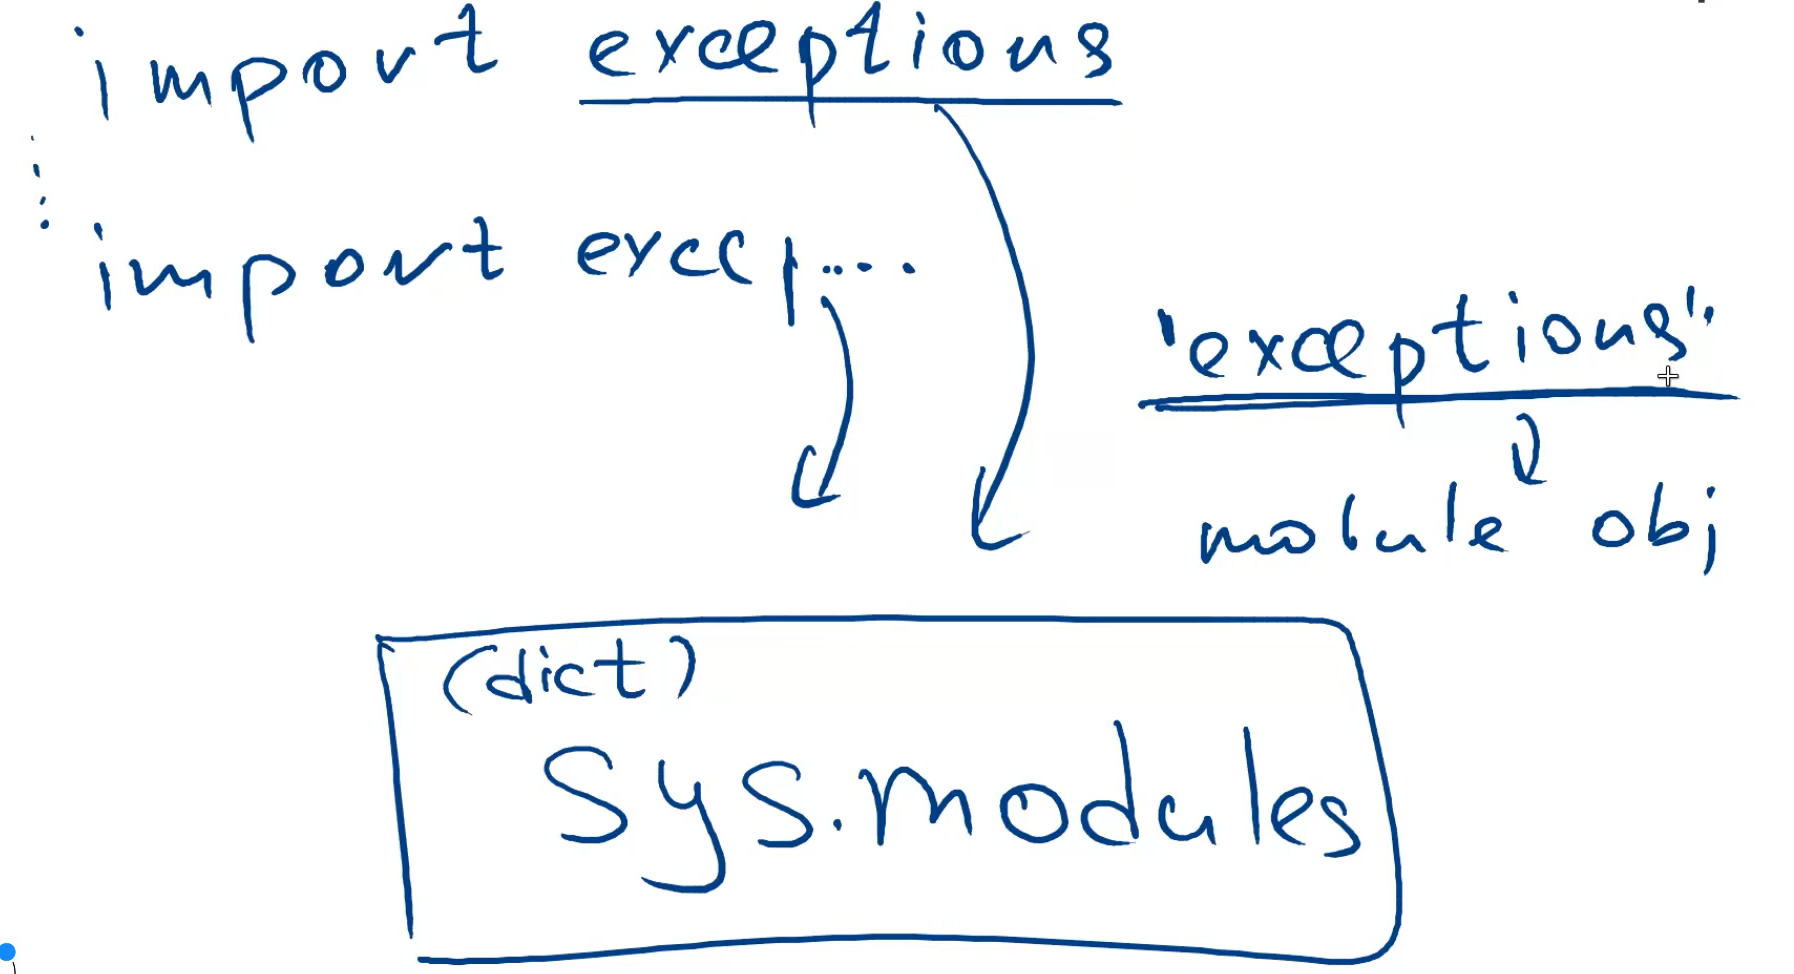

In [308]:
import sys
# Импортированные модули.
sys.modules

{'sys': <module 'sys' (built-in)>,
 'builtins': <module 'builtins' (built-in)>,
 '_frozen_importlib': <module '_frozen_importlib' (frozen)>,
 '_imp': <module '_imp' (built-in)>,
 '_thread': <module '_thread' (built-in)>,
 '_warnings': <module '_warnings' (built-in)>,
 '_weakref': <module '_weakref' (built-in)>,
 'winreg': <module 'winreg' (built-in)>,
 '_io': <module '_io' (built-in)>,
 'marshal': <module 'marshal' (built-in)>,
 'nt': <module 'nt' (built-in)>,
 '_frozen_importlib_external': <module '_frozen_importlib_external' (frozen)>,
 'time': <module 'time' (built-in)>,
 'zipimport': <module 'zipimport' (frozen)>,
 '_codecs': <module '_codecs' (built-in)>,
 'codecs': <module 'codecs' (frozen)>,
 'encodings.aliases': <module 'encodings.aliases' from 'C:\\Users\\79618\\anaconda3\\Lib\\encodings\\aliases.py'>,
 'encodings': <module 'encodings' from 'C:\\Users\\79618\\anaconda3\\Lib\\encodings\\__init__.py'>,
 'encodings.utf_8': <module 'encodings.utf_8' from 'C:\\Users\\79618\\anacond

In [309]:
import sys
print(id(sys))
import sys
print(id(sys))

1223508080608
1223508080608


Тот же самый объект. Т.е. импортирование осуществляется лишь раз.

In [314]:
# put your python code here
import datetime
date=[int(i) for i in input().split()]
days=int(input())



2016 4 20
14


In [316]:
import datetime
datetime.date(*date)

datetime.date(2016, 4, 20)

In [331]:
print(' '.join(map(str ,(datetime.date(*date)+datetime.timedelta(days)).timetuple()[:3])))

'2016 5 4'